In [1]:
import yfinance as yf
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler, LabelEncoder

tickers = [
    "AAPL","MSFT","GOOG","AMZN","META","NVDA","TSLA","BRK-B","JPM","V",
    "MA","NFLX","AMD","ORCL","CRM","ADBE","COST","WMT","KO","PEP",
    "AVGO","CSCO","QCOM","INTC","IBM","TXN","AMAT","MU","LRCX","KLAC",
    "GE","CAT","DE","HON","BA","RTX","LMT","NOC","UNP","UPS",
    "FDX","XOM","CVX","COP","SLB","EOG","MPC","PSX","VLO","OXY",
    "JNJ","PFE","MRK","ABBV","LLY","TMO","ABT","DHR","ISRG","MDT",
    "UNH","CI","HUM","CVS","ELV","GS","MS","BAC","WFC","C",
    "BLK","SCHW","AXP","SPGI","ICE","CME","BK","USB","PNC","TFC",
    "DIS","CMCSA","TMUS","T","VZ","MCD","SBUX","NKE","LOW","HD",
    "TJX","BKNG","MAR","HLT","UBER","SHOP","PLTR","SNOW","PANW","CRWD"
]

def add_features(df):
    df = df.copy()

    df["Return"] = df["Close"].pct_change()
    df["LogReturn"] = np.log(df["Close"] / df["Close"].shift(1))

    df["HighLowPct"] = (df["High"] - df["Low"]) / df["Close"]
    df["OpenClosePct"] = (df["Close"] - df["Open"]) / df["Open"]

    df["MA5"] = df["Close"].rolling(5).mean()
    df["MA20"] = df["Close"].rolling(20).mean()
    df["MA50"] = df["Close"].rolling(50).mean()

    df["DistMA20"] = df["Close"] / df["MA20"] - 1
    df["DistMA50"] = df["Close"] / df["MA50"] - 1

    df["Volatility20"] = df["Return"].rolling(20).std()

    df["VolumeChange"] = df["Volume"].pct_change()
    df["VolumeMA20"] = df["Volume"].rolling(20).mean()

    delta = df["Close"].diff()
    gain = delta.clip(lower=0)
    loss = -delta.clip(upper=0)

    avg_gain = gain.rolling(14).mean()
    avg_loss = loss.rolling(14).mean()

    rs = avg_gain / avg_loss
    df["RSI"] = 100 - (100 / (1 + rs))

    ema12 = df["Close"].ewm(span=12, adjust=False).mean()
    ema26 = df["Close"].ewm(span=26, adjust=False).mean()

    df["MACD"] = ema12 - ema26
    df["MACDSignal"] = df["MACD"].ewm(span=9, adjust=False).mean()
    df["MACDHist"] = df["MACD"] - df["MACDSignal"]

    return df.dropna()

train_dfs = []
test_dfs = []

for ticker in tickers:
    df = yf.download(ticker, start="2018-01-01", auto_adjust=True)
    df.columns = df.columns.get_level_values(0)

    df = add_features(df)

    df["Ticker"] = ticker

    train_dfs.append(df[:-100])   
    test_dfs.append(df[-100:])

train_df = pd.concat(train_dfs, ignore_index=True)
test_df = pd.concat(test_dfs, ignore_index=True)

encoder = LabelEncoder()

train_tickers = encoder.fit_transform(train_df["Ticker"])
test_tickers = encoder.transform(test_df["Ticker"])

train_df = train_df.drop(columns=["Ticker"])
test_df = test_df.drop(columns=["Ticker"])

scaler = StandardScaler()

train_data = scaler.fit_transform(train_df)
test_data = scaler.transform(test_df)



[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%********

In [2]:
def create_dataset(data, tickers, sequence_length=60):
    X = []
    X_tickers = []
    y = []

    for i in range(len(data) - sequence_length):
        if tickers[i] == tickers[i + sequence_length]:
            X.append(data[i:i + sequence_length])
            X_tickers.append(tickers[i])   
            y.append(int(data[i + sequence_length - 1][0] < data[i + sequence_length][0]))

    return np.array(X), np.array(X_tickers), np.array(y)

In [3]:
train_X, train_X_tickers, train_y = create_dataset(train_data, train_tickers)
test_X, test_X_tickers, test_y = create_dataset(test_data, test_tickers)

In [4]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, Dataset

In [5]:
class StockDataset(Dataset):
    def __init__(self, X, tickers, y):
        self.df = df
        self.X = torch.tensor(X, dtype= torch.float32)
        self.tickers = torch.tensor(tickers, dtype= torch.int)
        self.y = torch.tensor(y, dtype= torch.float32)

    def __len__(self):
        return self.X.shape[0]
    
    def __getitem__(self, idx):
        return self.X[idx], self.tickers[idx], self.y[idx]

In [6]:
train_ds = StockDataset(train_X, train_X_tickers, train_y)
test_ds = StockDataset(test_X, test_X_tickers, test_y)

In [7]:
train_dataloader = DataLoader(train_ds, 32)
test_dataloader = DataLoader(test_ds, 100000)

In [8]:
from transformer import FeatureEmbeddings, CorpEmbeddings, PositionalEncoding, build_encoder

In [9]:
feature_embedding = FeatureEmbeddings(21, 128).to('cuda')
corp_embedding = CorpEmbeddings(32, 100).to('cuda')
postional_encoding = PositionalEncoding(128, 60, 0.1).to('cuda')

In [10]:
class Classifier(nn.Module):
    def __init__(self, embedding_size):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(embedding_size, 256),
            nn.GELU(),
            nn.Dropout(0.2),
            nn.Linear(256, 1)
        )

    def forward(self, x):
        x = x[:, -1]
        return self.net(x)



In [11]:
classifier = Classifier(160).to('cuda')

In [12]:
loss_fn =  nn.BCEWithLogitsLoss()


In [13]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

In [14]:
model =  build_encoder(60, 160, 4, 2, 256, 0.1)

In [15]:
model = model.to(device)


In [16]:
from itertools import chain

In [17]:
optimizer = torch.optim.Adam(chain(model.parameters(),  feature_embedding.parameters(), classifier.parameters(), corp_embedding.parameters()), lr = 1e-4)

In [18]:
epochs = 50

In [19]:
training_loss = []

In [20]:
from tqdm import trange, tqdm

In [21]:
for epoch in range(epochs):
    total_loss = 0
    for X, ticker, y in tqdm(train_dataloader):
        optimizer.zero_grad()
        X = X.to(device)
        ticker = ticker.to(device)
        y = y.to(device)
        X = feature_embedding(X)
        ticker = corp_embedding(ticker)
        ticker = ticker.unsqueeze(1).expand(-1, 60, -1)
        X = postional_encoding(X)
        X  = torch.cat((X, ticker), dim = -1)
        out = model(X, None)
        out = classifier(out)
        loss = loss_fn(out.squeeze(-1), y)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    training_loss.append((total_loss / len(train_dataloader)))
    print(f"Loss : {total_loss / len(train_dataloader)}")



100%|██████████| 5958/5958 [00:28<00:00, 212.31it/s]


Loss : 0.6938093364358788


100%|██████████| 5958/5958 [00:26<00:00, 225.06it/s]


Loss : 0.6925764156192211


100%|██████████| 5958/5958 [00:26<00:00, 222.11it/s]


...

Loss : 0.6602273077327919


100%|██████████| 5958/5958 [00:29<00:00, 203.96it/s]


Loss : 0.6587278789866586


100%|██████████| 5958/5958 [00:28<00:00, 207.23it/s]

Loss : 0.6579468098812032


In [22]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)
import torch

model.eval()
feature_embedding.eval()
classifier.eval()

preds = []
targets = []

with torch.no_grad():
    for X, ticker, y in tqdm(test_dataloader):
        optimizer.zero_grad()
        X = X.to(device)
        ticker = ticker.to(device)
        y = y.to(device)
        X = feature_embedding(X)
        ticker = corp_embedding(ticker)
        ticker = ticker.unsqueeze(1).expand(-1, 60, -1)
        X = postional_encoding(X)
        X  = torch.cat((X, ticker), dim = -1)
        out = model(X, None)
        logits = classifier(out)

        probs = torch.sigmoid(logits)

        predictions = (probs >= 0.5).int()

        preds.extend(predictions.cpu().numpy())
        targets.extend(y.cpu().numpy())

print(f"Accuracy : {accuracy_score(targets, preds):.4f}")
print(f"Precision: {precision_score(targets, preds):.4f}")
print(f"Recall   : {recall_score(targets, preds):.4f}")
print(f"F1 Score : {f1_score(targets, preds):.4f}")

print("\nConfusion Matrix")
print(confusion_matrix(targets, preds))

print("\nClassification Report")
print(classification_report(targets, preds))

100%|██████████| 1/1 [00:00<00:00,  5.59it/s]


Accuracy : 0.5195
Precision: 0.5333
Recall   : 0.5359
F1 Score : 0.5346

Confusion Matrix
[[ 974  966]
 [ 956 1104]]

Classification Report
              precision    recall  f1-score   support

         0.0       0.50      0.50      0.50      1940
         1.0       0.53      0.54      0.53      2060

    accuracy                           0.52      4000
   macro avg       0.52      0.52      0.52      4000
weighted avg       0.52      0.52      0.52      4000



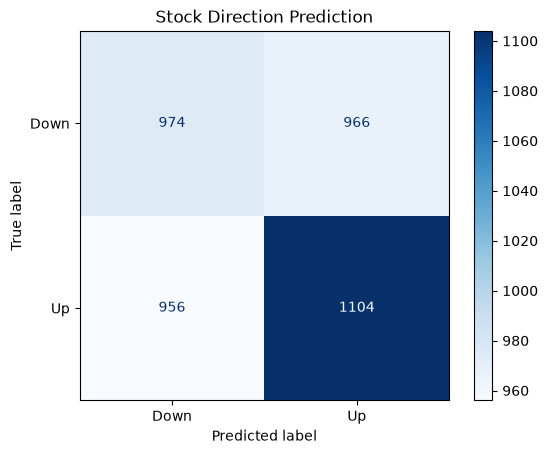

In [28]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

ConfusionMatrixDisplay.from_predictions(
    targets,
    preds,
    display_labels=["Down", "Up"],
    cmap="Blues"
)

plt.title("Stock Direction Prediction")
plt.savefig("confusion_matrix.png")
plt.show()


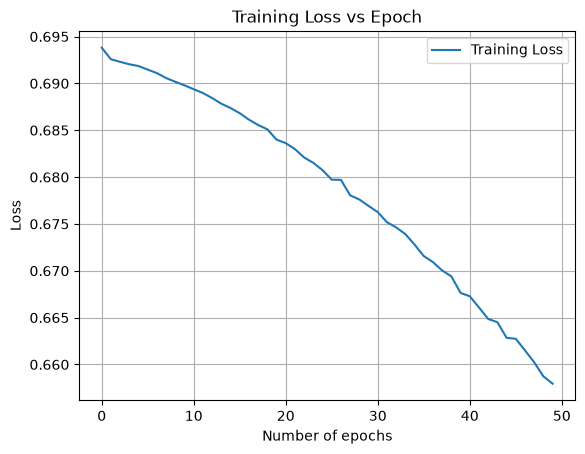

In [27]:
import matplotlib.pyplot as plt

plt.plot(training_loss, label = 'Training Loss')
plt.xlabel("Number of epochs")
plt.ylabel("Loss")
plt.grid()
plt.title("Training Loss vs Epoch")
plt.legend()
plt.savefig("training_loss.png")